# Testing atom_embedding

In [1]:
from atom_embedding import AtomFeaturizer, compute_shortest_path_matrix, count_topological_angles
from rdkit import Chem


featurizer = AtomFeaturizer(d_model=128)

mol = Chem.MolFromSmiles('c1ccccc1OOCC')
atom_embs = featurizer(mol)  # [n_atoms, 128]
path_matrix = compute_shortest_path_matrix(mol)
angle_counts = count_topological_angles(mol)


In [2]:
atom_embs.shape

torch.Size([10, 128])

In [3]:
angle_counts

defaultdict(int, {0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 3, 6: 1, 7: 1, 8: 1})

# test model

In [17]:
import torch
from rdkit import Chem

from atom_embedding import AtomFeaturizer
from model import GraphTransformerEncoder, GraphEncoder, MLPHead

# ---- Step 1: Define featurizer and model config ----
d_model = 128
n_heads = 4
n_layers = 4
dim_ff = 258
dropout = 0.1
mlp_hidden_dim = 257
mlp_head_depth = 2

# ---- Step 2: Build featurizer and encoder ----
featurizer = AtomFeaturizer(d_model=d_model)
encoder_model = GraphTransformerEncoder(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    dim_ff=dim_ff,
    dropout=dropout
)
graph_encoder = GraphEncoder(featurizer, encoder_model, use_cls_token=True)

# ---- Step 3: Build prediction head ----
head = MLPHead(input_dim=d_model, hidden_dim=mlp_hidden_dim, depth=mlp_head_depth)

# ---- Step 4: Convert SMILES to RDKit Mol ----
smiles = "c1ccccc1O"  # phenol
mol = Chem.MolFromSmiles(smiles)

# ---- Step 5: Run model (no training yet) ----
graph_encoder.eval()
head.eval()

with torch.no_grad():
    embedding = graph_encoder([mol])  # [1, d_model]
    output = head(embedding)          # [1, 1]

# ---- Step 6: Inspect output ----
print("Molecular embedding (randomly initialized):", embedding.shape)

print("Molecular output (randomly initialized):", output)


Molecular embedding (randomly initialized): torch.Size([1, 128])
Molecular output (randomly initialized): tensor([[0.1276]])


# Test raytune HyperOPt

In [18]:
!pip install "ray[tune]"

In [22]:
from ray import tune
from train import trainable
from model import MLPHead

search_space = {
    "d_model": tune.choice([128, 256, 512]),
    "n_heads": tune.choice([2, 4, 8]),
    "n_layers": tune.choice([2, 4, 6]),
    "dim_ff": tune.choice([256,]),
    "dropout": tune.uniform(0.0, 0.3),
    "mlp_hidden_dim": tune.choice([128]),
    "mlp_head_depth": tune.choice([2, 3]),
    "lr": tune.loguniform(1e-5, 1e-3),
    "batch_size": tune.choice([16, 64]),
    "use_cls_token": True,  
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "epochs": 10,
    "train_smiles": ["CCC", "CCO", "c1ccccc1CCO(O)"],  # insert data
    "train_labels": [1.0, 0.0, 0.0],
    "val_smiles": ["CCCCCC", "ClCCO", "c1cc(Cl)ccc1CCO(O)"],
    "val_labels": [1.0, 0.0, 0.0]
}

tune.run(trainable, config=search_space, num_samples=20)


2025-03-26 19:13:24,787	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


Trial name,val_loss
trainable_eb077_00000,0.152829
trainable_eb077_00001,0.00248658
trainable_eb077_00002,0.0679148
trainable_eb077_00003,0.187499
trainable_eb077_00004,0.162231
trainable_eb077_00005,0.0335755
trainable_eb077_00006,0.0147445
trainable_eb077_00007,0.118604
trainable_eb077_00008,0.151694
trainable_eb077_00009,0.0886251


2025-03-26 19:13:39,113	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/Users/lsieben/ray_results/trainable_2025-03-26_19-13-24' in 0.0134s.
2025-03-26 19:13:39,118	INFO tune.py:1041 -- Total run time: 14.33 seconds (14.30 seconds for the tuning loop).


# Testing Integrated Gradients

In [1]:
!pip install captum

In [2]:
%load_ext autoreload

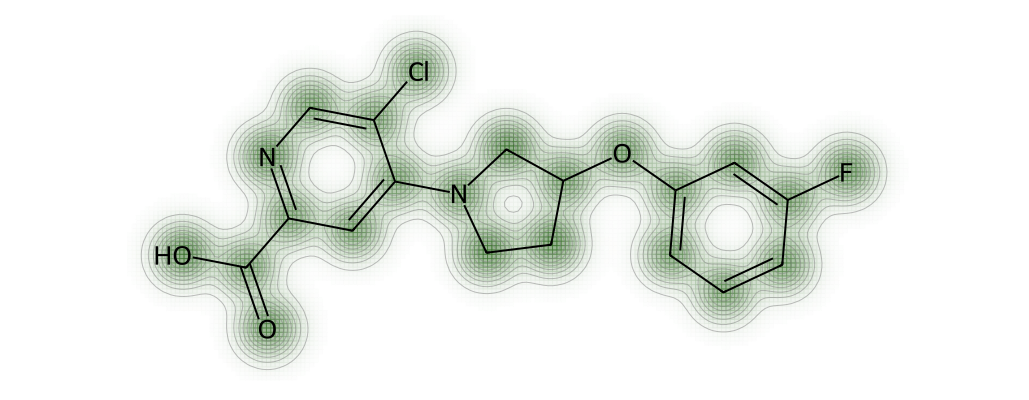

In [9]:
from interpret import load_model, interpret_smiles
%autoreload 2

config = {"d_model": 128, "n_layers": 4, "n_heads": 4, "dim_ff": 256, "dropout": 0.1,
           "mlp_hidden_dim": 128, "mlp_head_depth": 2, "use_cls_token": True}
encoder, head = load_model(config)
fig, scores = interpret_smiles("OC(C1=NC=C(Cl)C(N2CC(OC3=CC=CC(F)=C3)CC2)=C1)=O", encoder, head)  # Phenol
fig

# Walkthrough

In [8]:
%load_ext autoreload

In [1]:
import pandas as pd
from train import train_model, trainable, predict, MoleculeDataset
from model import InterpreMol
from rdkit import Chem
from ray import tune


train_SA = pd.read_csv("/Users/lsieben/Desktop/AL_for_Broadspectrum/Iteration_0/data/Collins/Collins_SA_cleaned.csv").sample(n=300)
train_SA.head()

,SMILES,Hit
18376,CN(C)CC(=O)N[C@@H]1CC[C@@H](CCNS(=O)(=O)c2cccc...,0.0
32148,Cc1cc(C)c(S(=O)(=O)NCCO)cc1C,0.0
9060,C[C@H](CO)N1C[C@H](C)[C@H](CN(C)C(=O)Nc2ccccc2...,0.0
12488,CC(C)(C)OC(=O)N1CCC(N)CC1,0.0
33554,C[C@H](CO)N1C[C@H](C)[C@H](CN(C)C(=O)Nc2cccc3c...,0.0


In [2]:
# Convert your DataFrame into SMILES and binary labels
smiles = train_SA["SMILES"].tolist()
labels = train_SA["Hit"].astype(float).tolist()

# Split into train/val (can use sklearn too)
split = int(0.8 * len(smiles))
train_smiles, val_smiles = smiles[:split], smiles[split:]
train_labels, val_labels = labels[:split], labels[split:]

In [15]:
config = {
    "d_model": 128,
    "n_layers": 4,
    "n_heads": 4,
    "dim_ff": 256,
    "dropout": 0.1,
    "mlp_hidden_dim": 256,
    "mlp_head_depth": 2,
    "out_dim": 1,  # single output
    "use_cls_token": True,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "batch_size": 32,
    "epochs": 70,
    "loss": "bce",  # binary classification
    "device": "cpu",

    "train_smiles": train_smiles,
    "train_labels": train_labels,
    "val_smiles": val_smiles,
    "val_labels": val_labels,
}


In [16]:
model, val_loss = train_model(config)
print(f"Final validation loss: {val_loss}")
model.save("final_model.pt")

[Epoch 1] Val Loss: 0.2599


[Epoch 2] Val Loss: 0.1519


[Epoch 3] Val Loss: 0.1149


[Epoch 4] Val Loss: 0.0979


[Epoch 5] Val Loss: 0.0901


...

[Epoch 66] Val Loss: 0.0928


[Epoch 67] Val Loss: 0.0931


[Epoch 68] Val Loss: 0.0923


[Epoch 69] Val Loss: 0.0923


[Epoch 70] Val Loss: 0.0936
Final validation loss: 0.0813023466616869


In [5]:
search_space = config.copy()
search_space["lr"] = tune.loguniform(1e-5, 1e-3)
search_space["weight_decay"] = tune.uniform(1e-6, 1e-2)
search_space["dropout"] = tune.uniform(0.0, 0.5)

analysis = tune.run(
    trainable,
    config=search_space,
    num_samples=10,
    metric="val_loss",
    mode="min",
    resources_per_trial={"cpu": 1}
)

best_config = analysis.get_best_config("val_loss", "min")
print("Best config:", best_config)

# Train final model with best config
best_config["train_smiles"] = train_smiles
best_config["train_labels"] = train_labels
best_config["val_smiles"] = val_smiles
best_config["val_labels"] = val_labels
best_config["device"] = "cpu"

final_model, best_loss = train_model(best_config)
final_model.save("best_model.pt")

2025-03-26 22:16:25,334	INFO worker.py:1852 -- Started a local Ray instance.
2025-03-26 22:16:25,905	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2025-03-26 22:16:25,907	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


Trial name,val_loss
trainable_7c48c_00000,0.0835977
trainable_7c48c_00001,0.176693
trainable_7c48c_00002,0.0826193
trainable_7c48c_00003,0.217625
trainable_7c48c_00004,0.0810362
trainable_7c48c_00005,0.130081
trainable_7c48c_00006,0.12054
trainable_7c48c_00007,0.141878
trainable_7c48c_00008,0.0826406
trainable_7c48c_00009,0.0817277


2025-03-26 22:17:23,944	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/Users/lsieben/ray_results/trainable_2025-03-26_22-16-25' in 0.0105s.
2025-03-26 22:17:23,949	INFO tune.py:1041 -- Total run time: 58.04 seconds (57.93 seconds for the tuning loop).


Best config: {'d_model': 128, 'n_layers': 4, 'n_heads': 4, 'dim_ff': 256, 'dropout': 0.13791804298483534, 'mlp_hidden_dim': 256, 'mlp_head_depth': 2, 'out_dim': 1, 'use_cls_token': True, 'lr': 0.00033486703702178703, 'weight_decay': 0.009193129210117905, 'batch_size': 32, 'epochs': 7, 'loss': 'bce', 'device': 'cpu', 'train_smiles': ['CN(C)CC(=O)N[C@@H]1CC[C@@H](CCNS(=O)(=O)c2ccccc2)O[C@@H]1CO', 'Cc1cc(C)c(S(=O)(=O)NCCO)cc1C', 'C[C@H](CO)N1C[C@H](C)[C@H](CN(C)C(=O)Nc2ccccc2C(F)(F)F)OCc2cnnn2CCCC1=O', 'CC(C)(C)OC(=O)N1CCC(N)CC1', 'C[C@H](CO)N1C[C@H](C)[C@H](CN(C)C(=O)Nc2cccc3ccccc23)Oc2c(NC(=O)Nc3cccc4ccccc34)cccc2C1=O', 'CC(C)CC#Cc1ccc2c(c1)O[C@@H](CN(C)C(=O)c1ccccn1)[C@H](C)CN([C@H](C)CO)S2(=O)=O', 'C[C@@H]1CCCCO[C@H](CN(C)S(=O)(=O)c2ccccc2)[C@@H](C)CN([C@H](C)CO)C(=O)c2cc(NC(=O)NC3CCCCC3)ccc2O1', 'Cc1ccc(S(=O)(=O)N(C)C[C@@H]2Oc3ccc(NC(=O)Cn4cnnn4)cc3C(=O)N([C@H](C)CO)C[C@@H]2C)cc1', 'CCOc1ccc(N2C(=O)/C(=C/C=C/c3ccccc3OC)S(=O)(=O)[C@@H]2c2cccc([N+](=O)[O-])c2)cc1', 'Cc1ccc(CNS(=O)(=O)N

[Epoch 1] Val Loss: 0.0880


...

[Epoch 4] Val Loss: 0.0812


[Epoch 5] Val Loss: 0.0817


[Epoch 6] Val Loss: 0.0824


[Epoch 7] Val Loss: 0.0822


(raylet) [2025-03-27 09:20:39,763 E 34402 955840] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-03-26_22-16-24_413281_34151 is over 95% full, available space: 22.9575 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.
(raylet) [2025-03-27 09:20:49,828 E 34402 955840] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-03-26_22-16-24_413281_34151 is over 95% full, available space: 22.7019 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.
(raylet) [2025-03-27 09:20:59,926 E 34402 955840] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-03-26_22-16-24_413281_34151 is over 95% full, available space: 22.5773 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.
(raylet) [2025-03-27 09:21:09,938 E 34402 955840] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-03-26_22-16-24_413281_34151 is over 95% full, available space: 22.4523 GB; capacity: 460.432 GB. Object creation will fa

In [17]:
from train import predict
from model import InterpreMol
%autoreload 2

# Load model and test data
model = InterpreMol.load("final_model.pt", device="cpu")
test_dataset = MoleculeDataset(train_smiles+val_smiles, train_labels+val_labels)

predictions = predict(model, test_dataset, batch_size=64, classification=True)

train_SA["pred"] = predictions


In [18]:
train_SA[train_SA['Hit'] == 1]


,SMILES,Hit,pred,Predicted_Prob
27667,c1ccc(Nc2nc3c(ccc4ccccc43)s2)cc1,1.0,0.980249,0.039915
28585,C[C@H]1CN([C@@H](C)CO)S(=O)(=O)c2ccc(C#Cc3cccc...,1.0,0.004920,0.015392
11919,O=C(NCCCCCC(O)=NO)OCc1ccc(CO[C@@H]2C[C@H](c3cc...,1.0,0.951783,0.016839
5994,CCc1ccc(Nc2c3c(nc4ccccc24)CCC3)cc1,1.0,0.965262,0.027467
405,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,1.0,0.942608,0.018525
8849,C[C@H](CO)N1C[C@H](C)[C@@H](CN(C)Cc2ccc(C(F)(F...,1.0,0.003332,0.014535


In [13]:
# Reload model
model = InterpreMol.load("best_model.pt", device="cpu")

# Create dataset from original DataFrame
full_dataset = MoleculeDataset(smiles, labels)

# Predict
predictions = predict(model, full_dataset, batch_size=64, device="cpu")

# Store back into DataFrame if needed
train_SA["Predicted_Prob"] = predictions


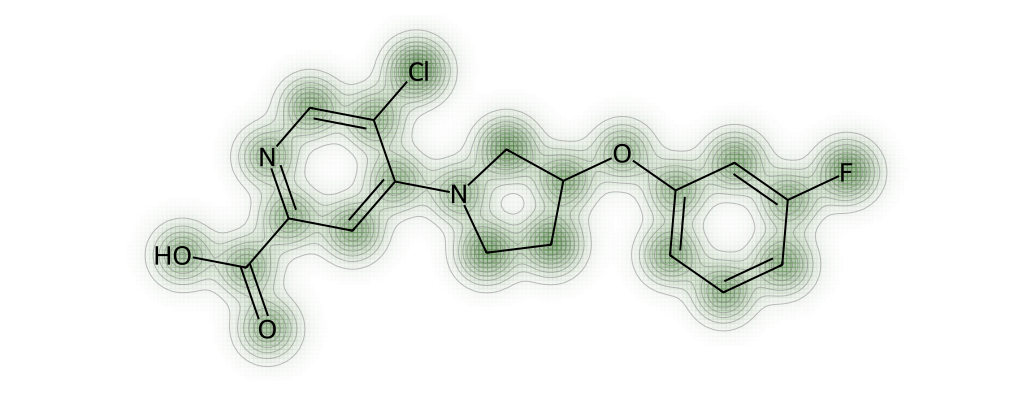

In [14]:
from model import InterpreMol
from interpret import interpret_smiles  # still valid if interpret_smiles accepts InterpreMol

model = InterpreMol.load("final_model.pt", device="cpu")

fig, scores = interpret_smiles(
    smiles="OC(C1=NC=C(Cl)C(N2CC(OC3=CC=CC(F)=C3)CC2)=C1)=O",
    model=model,
    target=0  # or omit for default
)
fig
